## Hammer Throw Regression

#### Linear Regression

model coef = [1.88765877 3.09808894]
Mean absolute error=19.880
Runtime = 0.00594 sec


Text(0, 0.5, 'Distance (m)')

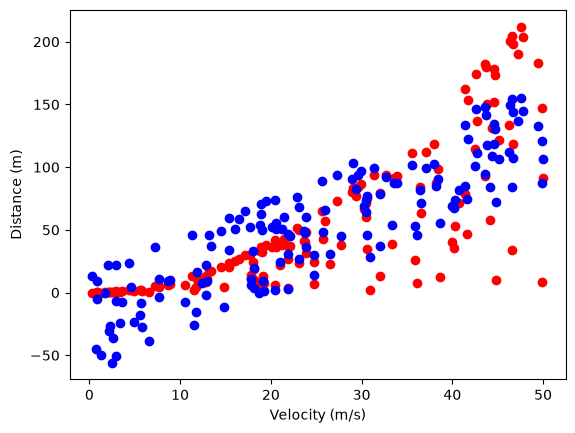

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import timeit

X = np.load('data_X.npy')
Y = np.load('data_Y.npy')

start = timeit.default_timer()
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3)

model = LinearRegression()
model.fit(X_train, y_train)
print("model coef =", model.coef_)
predictions = model.predict(X_test)
print(f"Mean absolute error={mean_absolute_error(y_test, predictions):.3f}")
stop = timeit.default_timer()
print(f"Runtime = {stop-start:.5f} sec")

#print(X_test.shape)
#print(predictions.shape)
plt.scatter(X_test[:,1], y_test, c='r')
plt.scatter(X_test[:,1], predictions, c='b')
plt.xlabel('Velocity (m/s)')
plt.ylabel('Distance (m)')

#### Nearest Neightbors Regression

Runtime = 0.00103 sec
Mean absolute error=2.281


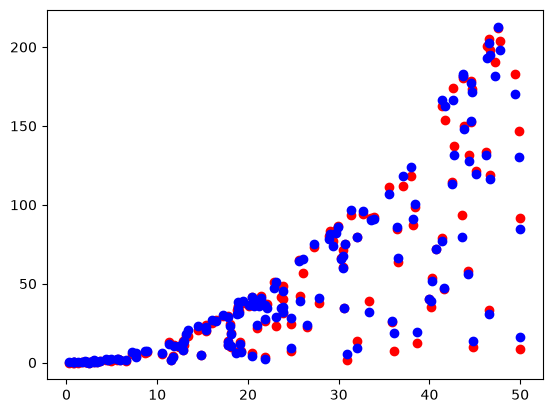

In [3]:
from sklearn import neighbors

start = timeit.default_timer()
n_neighbors = 5
knn = neighbors.KNeighborsRegressor(n_neighbors, weights='distance')
predictions = knn.fit(X_train, y_train).predict(X_test)

stop = timeit.default_timer()
print(f"Runtime = {stop-start:.5f} sec")

print(f"Mean absolute error={mean_absolute_error(y_test, predictions):.3f}")
plt.scatter(X_test[:,1], y_test, c='r')
plt.scatter(X_test[:,1], predictions, c='b')

#### Huber Regressor
Linear regression that is robust to outliers.

In [4]:
from sklearn.linear_model import HuberRegressor

huber = HuberRegressor().fit(X_train, y_train)
predictions = huber.predict(X_test)
print(f"Mean absolute error={mean_absolute_error(y_test, predictions):.3f}")

Mean absolute error=19.317


### Polynomial Regression
See also: https://www.statology.org/sklearn-polynomial-regression/

model coef = [-1.81628015e-04 -6.18636179e-04  3.69278261e-03 -2.03727217e-02
  1.99114724e-04 -2.48449326e-04  1.16566374e-03  4.38526212e-03
 -1.37068205e-05  3.83253760e-06 -1.75061455e-05 -4.22655483e-05
 -6.53626466e-06  4.15151403e-08]
Mean absolute error=0.107


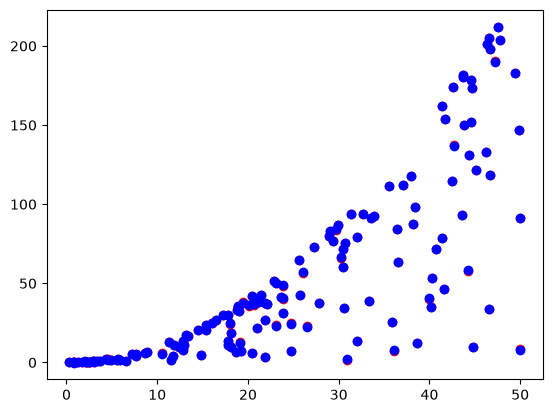

In [5]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=4, include_bias=False)
X_train_new = poly.fit_transform(X_train)
model = LinearRegression()
model.fit(X_train_new, y_train)
print("model coef =", model.coef_)

X_test_new = poly.fit_transform(X_test)
predictions = model.predict(X_test_new)
print(f"Mean absolute error={mean_absolute_error(y_test, predictions):.3f}")
plt.scatter(X_test[:,1], y_test, c='r')
plt.scatter(X_test[:,1], predictions, c='b')

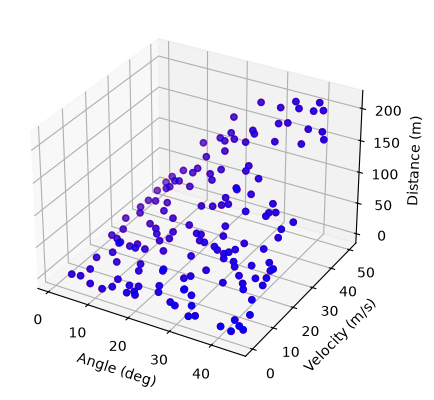

In [6]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X_test[:,0], X_test[:,1], y_test, c='r')
ax.scatter(X_test[:,0], X_test[:,1], predictions, c='b')
ax.set_xlabel('Angle (deg)')
ax.set_ylabel('Velocity (m/s)')
ax.set_zlabel('Distance (m)')
plt.show()